# Non-determinism analysis across 3 identical inference runs

Same 100 test cases, same git commit, same model (`gpt-5-1`), same prompts (verified via hashes below) — yet routing / tool usage / tool params differ across runs. This notebook isolates **where** the divergence happens and **how much** propagates to the deterministic scorers.

**Runs**

| run | source_run_id |
|---|---|
| 1 | `30bca13482944fc0a0ca4eed34a51390` |
| 2 | `2bacd8bb488a4e79986749e1703098fa` |
| 3 | `5abe9d81bba14d91af922a1ca0a52f4b` |

Outline: (1) config-drift sanity check, (2) routing diff, (3) tool-name diff, (4) tool-parameter diff, (5) downstream scorer impact, (6) inspect agent prompts, (7) findings & recommendations.

In [1]:
from __future__ import annotations
import ast, json, hashlib
from collections import Counter
from pathlib import Path
import pandas as pd

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 200)

DATA_DIR = Path('/Users/SG7CB/Developer/input_traces')
RUNS = {
    'run1': '30bca13482944fc0a0ca4eed34a51390',
    'run2': '2bacd8bb488a4e79986749e1703098fa',
    'run3': '5abe9d81bba14d91af922a1ca0a52f4b',
}
CSV_PATHS = {r: DATA_DIR / f'enriched_traces_{rid}.csv' for r, rid in RUNS.items()}
PROMPT_PATHS = {r: DATA_DIR / f'prompt_{rid}.json' for r, rid in RUNS.items()}

JOIN_KEY = 'test_case_id'

# knowledge_search.queries is a free-form retrieval input, not a scored parameter,
# so it is excluded from the per-tool / per-key parameter-drift analysis below.
# Tool-set / routing analysis (sections 2-3) still includes it.
EXCLUDE_TOOLS_FOR_PARAM_ANALYSIS = {'knowledge_search'}

def _safe_parse(x):
    """actual_tool_calls / actual_agents_path are Python repr strings — use ast.literal_eval."""
    if not isinstance(x, str) or not x.strip() or x.strip() in {'nan', 'None', '[]'}:
        return []
    try:
        return ast.literal_eval(x)
    except Exception:
        try:
            return json.loads(x)
        except Exception:
            return []

dfs = {r: pd.read_csv(p) for r, p in CSV_PATHS.items()}
for r, df in dfs.items():
    print(f'{r}: rows={len(df)}, unique test_case_id={df[JOIN_KEY].nunique()}')

run1: rows=100, unique test_case_id=100
run2: rows=100, unique test_case_id=100
run3: rows=100, unique test_case_id=100


## 1. Config-drift sanity check

If any of these differ across runs, the "non-determinism" is actually environment drift, not LLM stochasticity. Expectation: **all identical**.

In [2]:
sanity_cols = [
    'main_agent_prompt_hash', 'daily_banking_agent_prompt_hash',
    'tool_descriptions_hash', 'model', 'git_commit', 'architecture',
]

# Per-test_case_id consistency: for each (test_case_id, column) the value should match across all 3 runs.
sanity_rows = []
merged_sanity = None
for r, df in dfs.items():
    sub = df[[JOIN_KEY] + sanity_cols].rename(columns={c: f'{c}__{r}' for c in sanity_cols})
    merged_sanity = sub if merged_sanity is None else merged_sanity.merge(sub, on=JOIN_KEY, how='outer')

for col in sanity_cols:
    cols_r = [f'{col}__{r}' for r in RUNS]
    mism = (merged_sanity[cols_r].nunique(axis=1, dropna=False) > 1).sum()
    sanity_rows.append({'column': col, 'test_cases_with_mismatch_across_runs': int(mism)})

print('Per test_case_id mismatch counts (0 == fully consistent across the 3 runs):')
print(pd.DataFrame(sanity_rows).to_string(index=False))

Per test_case_id mismatch counts (0 == fully consistent across the 3 runs):
                         column  test_cases_with_mismatch_across_runs
         main_agent_prompt_hash                                     0
daily_banking_agent_prompt_hash                                     0
         tool_descriptions_hash                                     0
                          model                                     0
                     git_commit                                     0
                   architecture                                     0


## 2. Routing divergence (`actual_agent`, `actual_agents_path`)

Routing = which agent(s) the supervisor delegated to. We look at two views:
- **Terminal agent** (`actual_agent`): the agent that produced the final answer.
- **Agent path** (`actual_agents_path`): the ordered sequence of agents visited.

For each `test_case_id`, count distinct values across the 3 runs. `=1` means the runs agree.

In [3]:
def _normalize_path(x):
    seq = _safe_parse(x) if isinstance(x, str) else x
    return tuple(seq) if isinstance(seq, (list, tuple)) else ()

routing = None
for r, df in dfs.items():
    sub = df[[JOIN_KEY, 'actual_agent', 'actual_agents_path']].copy()
    sub['actual_agents_path'] = sub['actual_agents_path'].map(_normalize_path)
    sub = sub.rename(columns={'actual_agent': f'agent__{r}', 'actual_agents_path': f'path__{r}'})
    routing = sub if routing is None else routing.merge(sub, on=JOIN_KEY, how='outer')

agent_cols = [f'agent__{r}' for r in RUNS]
path_cols = [f'path__{r}' for r in RUNS]

routing['n_distinct_agents'] = routing[agent_cols].nunique(axis=1, dropna=False)
routing['n_distinct_paths'] = routing[path_cols].apply(lambda row: len(set(row)), axis=1)

print('Terminal-agent disagreement distribution:')
print(routing['n_distinct_agents'].value_counts().rename_axis('distinct values across 3 runs').to_string())
print('\nAgent-path disagreement distribution:')
print(routing['n_distinct_paths'].value_counts().rename_axis('distinct values across 3 runs').to_string())

disagree_terminal = routing[routing['n_distinct_agents'] > 1]
disagree_path = routing[routing['n_distinct_paths'] > 1]
print(f'\nCases where terminal agent differs across runs: {len(disagree_terminal)} / {len(routing)}')
print(f'Cases where agent path differs across runs:     {len(disagree_path)} / {len(routing)}')

Terminal-agent disagreement distribution:
distinct values across 3 runs
1    100

Agent-path disagreement distribution:
distinct values across 3 runs
1    100

Cases where terminal agent differs across runs: 0 / 100
Cases where agent path differs across runs:     0 / 100


In [4]:
# Examples: the test cases with the most routing instability, joined with the user_query and expected_agent
examples = disagree_path.head(15).merge(
    dfs['run1'][[JOIN_KEY, 'user_query', 'expected_agent']],
    on=JOIN_KEY, how='left'
)
examples[['test_case_id', 'expected_agent', 'agent__run1', 'agent__run2', 'agent__run3', 'user_query']]

,test_case_id,expected_agent,agent__run1,agent__run2,agent__run3,user_query


## 3. Tool-usage divergence (which tools were called)

Compare the **set** of tool names called per test case across runs. We also count adds / drops between adjacent runs to see if any one run is an outlier.

In [5]:
def _tool_names(cell):
    calls = _safe_parse(cell)
    out = []
    for c in calls or []:
        if isinstance(c, dict):
            name = c.get('tool') or c.get('name')
            if name:
                out.append(str(name))
    return out

tu = None
for r, df in dfs.items():
    sub = df[[JOIN_KEY, 'actual_tool_calls']].copy()
    sub[f'tool_names__{r}'] = sub['actual_tool_calls'].map(_tool_names)
    sub[f'tool_set__{r}'] = sub[f'tool_names__{r}'].map(frozenset)
    sub = sub.drop(columns=['actual_tool_calls'])
    tu = sub if tu is None else tu.merge(sub, on=JOIN_KEY, how='outer')

set_cols = [f'tool_set__{r}' for r in RUNS]
tu['n_distinct_tool_sets'] = tu[set_cols].apply(lambda row: len(set(row)), axis=1)

# Per-case Jaccard between pair-wise runs (lower = more disagreement)
def _jaccard(a, b):
    a, b = set(a), set(b)
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b)

tu['jaccard_12'] = tu.apply(lambda r: _jaccard(r['tool_set__run1'], r['tool_set__run2']), axis=1)
tu['jaccard_13'] = tu.apply(lambda r: _jaccard(r['tool_set__run1'], r['tool_set__run3']), axis=1)
tu['jaccard_23'] = tu.apply(lambda r: _jaccard(r['tool_set__run2'], r['tool_set__run3']), axis=1)
tu['mean_jaccard'] = tu[['jaccard_12', 'jaccard_13', 'jaccard_23']].mean(axis=1)

print('Tool-set agreement across runs:')
print(tu['n_distinct_tool_sets'].value_counts().rename_axis('# distinct tool sets').to_string())
print(f'\nMean pairwise Jaccard (1.0 = perfect agreement): {tu["mean_jaccard"].mean():.3f}')
print(f'Cases with identical tool sets across all 3 runs: {(tu["n_distinct_tool_sets"] == 1).sum()} / {len(tu)}')

Tool-set agreement across runs:
# distinct tool sets
1    97
2     3

Mean pairwise Jaccard (1.0 = perfect agreement): 0.987
Cases with identical tool sets across all 3 runs: 97 / 100


In [6]:
# Which tools most often get added/dropped non-deterministically?
# For each test_case_id, compute symmetric-difference per pair and tally tool names.
drift = Counter()
for _, row in tu.iterrows():
    s1, s2, s3 = row['tool_set__run1'], row['tool_set__run2'], row['tool_set__run3']
    for a, b in ((s1, s2), (s1, s3), (s2, s3)):
        drift.update(set(a) ^ set(b))

drift_df = pd.DataFrame(drift.most_common(20), columns=['tool', 'pairwise_disagreement_count'])
print('Top tools that appear inconsistently across runs (counted across all 3 pair-comparisons × 100 cases):')
print(drift_df.to_string(index=False))

Top tools that appear inconsistently across runs (counted across all 3 pair-comparisons × 100 cases):
                          tool  pairwise_disagreement_count
              knowledge_search                            2
george-gcg-store_getStoreItems                            2
george-gcg-product_getAccounts                            2


In [7]:
# Show concrete examples of tool-set disagreement
tu_examples = (tu[tu['n_distinct_tool_sets'] > 1]
               .sort_values('mean_jaccard')
               .head(10)
               .merge(dfs['run1'][[JOIN_KEY, 'user_query']], on=JOIN_KEY, how='left'))

for _, r in tu_examples.iterrows():
    print(f'--- test_case_id={r[JOIN_KEY]} (mean_jaccard={r["mean_jaccard"]:.2f})')
    print(f'  query: {str(r["user_query"])[:140]}')
    print(f'  run1 tools: {sorted(r["tool_set__run1"])}')
    print(f'  run2 tools: {sorted(r["tool_set__run2"])}')
    print(f'  run3 tools: {sorted(r["tool_set__run3"])}')

--- test_case_id=smoke-034 (mean_jaccard=0.33)
  query: How do I open a new account?
  run1 tools: ['george-gcg-store_getStoreItems']
  run2 tools: []
  run3 tools: []
--- test_case_id=smoke-025 (mean_jaccard=0.67)
  query: What is the current interest rate on my savings account?
  run1 tools: ['george-gcg-product_getAccounts']
  run2 tools: ['george-gcg-product_getAccounts']
  run3 tools: ['george-gcg-product_getAccounts', 'knowledge_search']
--- test_case_id=smoke-046 (mean_jaccard=0.67)
  query: How much did my partner spend from our shared account this month?
  run1 tools: ['analyze_transactions']
  run2 tools: ['analyze_transactions']
  run3 tools: ['analyze_transactions', 'george-gcg-product_getAccounts']


## 4. Tool-parameter divergence

For tools that **were** called in all 3 runs for the same test case, do the argument dicts match? We bucket disagreement by:
- **Same keys, different values** — semantic drift (e.g. different filter value, different limit).
- **Different key sets** — the model passed extra/missing parameters.

> **Note:** `knowledge_search` is excluded from this analysis. Its `queries` parameter is a free-form retrieval input (not a scored parameter), so drift there is expected and irrelevant to `tool_parameter_score`. Tool-set diffs in Section 3 still include it.

In [8]:
def _canonical(v):
    """Stable canonical form for an arg value so dicts can be compared."""
    if isinstance(v, dict):
        return tuple(sorted((k, _canonical(v[k])) for k in v))
    if isinstance(v, (list, tuple)):
        return tuple(_canonical(x) for x in v)
    return v

def _calls_by_tool(cell):
    """Map tool_name -> list of arg dicts (one entry per call, preserving order)."""
    out: dict[str, list[dict]] = {}
    for c in _safe_parse(cell) or []:
        if not isinstance(c, dict):
            continue
        name = c.get('tool') or c.get('name')
        args = c.get('arguments') if c.get('arguments') is not None else c.get('parameters')
        if not isinstance(args, dict):
            args = {}
        out.setdefault(str(name), []).append(args)
    return out

calls_per_run = {r: dfs[r].set_index(JOIN_KEY)['actual_tool_calls'].map(_calls_by_tool).to_dict()
                  for r in RUNS}

param_drift_rows = []
for tc in dfs['run1'][JOIN_KEY].unique():
    c1, c2, c3 = (calls_per_run[r].get(tc, {}) for r in RUNS)
    common_tools = (set(c1) & set(c2) & set(c3)) - EXCLUDE_TOOLS_FOR_PARAM_ANALYSIS
    for tool in common_tools:
        # take first call of this tool per run (most tools are single-call in this pipeline)
        a1, a2, a3 = c1[tool][0], c2[tool][0], c3[tool][0]
        k1, k2, k3 = set(a1), set(a2), set(a3)
        key_diff = (k1 != k2) or (k1 != k3)
        canon = {_canonical(a) for a in (a1, a2, a3)}
        value_diff = (not key_diff) and (len(canon) > 1)
        if key_diff or value_diff:
            param_drift_rows.append({
                'test_case_id': tc,
                'tool': tool,
                'drift_type': 'key_set_differs' if key_diff else 'value_differs',
                'run1_args': a1, 'run2_args': a2, 'run3_args': a3,
            })

param_drift = pd.DataFrame(param_drift_rows)
print(f'Tool-parameter drift instances (excluding {sorted(EXCLUDE_TOOLS_FOR_PARAM_ANALYSIS)}): {len(param_drift)}')
if len(param_drift):
    print('\nBy drift type:')
    print(param_drift['drift_type'].value_counts().to_string())
    print('\nTop tools with parameter drift:')
    print(param_drift['tool'].value_counts().head(15).to_string())

Tool-parameter drift instances (excluding ['knowledge_search']): 42

By drift type:
drift_type
key_set_differs    36
value_differs       6

Top tools with parameter drift:
tool
analyze_transactions              31
george-gcg-product_getCards        7
george-gcg-product_getAccounts     4


In [9]:
# Show concrete parameter-drift examples (truncated)
if len(param_drift):
    for _, r in param_drift.head(10).iterrows():
        print(f'--- test_case_id={r["test_case_id"]} | tool={r["tool"]} | {r["drift_type"]}')
        for run_col in ('run1_args', 'run2_args', 'run3_args'):
            print(f'  {run_col}: {str(r[run_col])[:200]}')

--- test_case_id=smoke-099 | tool=george-gcg-product_getAccounts | key_set_differs
  run1_args: {'ownTransferPossible': True}
  run2_args: {'ownTransferPossible': True}
  run3_args: {'ownTransferPossible': True, 'ownedByCurrentUser': True}
--- test_case_id=smoke-098 | tool=george-gcg-product_getCards | key_set_differs
  run1_args: {}
  run2_args: {}
  run3_args: {'type': 'CREDIT', 'state': 'ACTIVE'}
--- test_case_id=smoke-097 | tool=george-gcg-product_getCards | key_set_differs
  run1_args: {'type': 'CREDIT', 'state': 'ACTIVE'}
  run2_args: {}
  run3_args: {'type': 'CREDIT', 'state': 'ACTIVE'}
--- test_case_id=smoke-096 | tool=george-gcg-product_getCards | key_set_differs
  run1_args: {'accountId': 'B71EE54C327F42ED'}
  run2_args: {'accountId': 'B71EE54C327F42ED'}
  run3_args: {}
--- test_case_id=smoke-090 | tool=george-gcg-product_getAccounts | key_set_differs
  run1_args: {'search': 'Home Repairs'}
  run2_args: {'search': 'Home Repairs', 'ownedByCurrentUser': True}
  run3_args: {'sea

### 4.1 Runtime-equivalent parameter drift

The raw drift count above is intentionally strict: it compares emitted argument dictionaries as text-like structures. That is useful for seeing model surface variation, but it can over-count harmless runtime-equivalent differences such as omitted server defaults or `MAIN_DATE_*` versus `EXECUTION_DATE_*` sort aliases.

This section replays the same comparison through the shared scorer-equivalence helper used by the API import notebook. Use the **relaxed** counts below as the headline number for behavioral parameter drift.

In [10]:
import sys
from IPython.display import display

# Make the local repo importable if this notebook is launched from its own folder.
_repo_root = Path.cwd()
while _repo_root != _repo_root.parent and not (_repo_root / 'hg_ds_evals').is_dir():
    _repo_root = _repo_root.parent
if (_repo_root / 'hg_ds_evals').is_dir() and str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from hg_ds_evals.evals.api_utils import (
    compute_tool_parameter_equivalence,
    find_expected_default_parameters,
)

# Refresh from disk so this section reflects the latest API import-notebook reruns,
# even if this analysis notebook kernel was already alive before those CSVs changed.
dfs = {run_name: pd.read_csv(path) for run_name, path in CSV_PATHS.items()}
print('Reloaded enriched trace CSVs:')
for run_name, df in dfs.items():
    print(f'  {run_name}: rows={len(df)}, unique {JOIN_KEY}={df[JOIN_KEY].nunique()}')


def _as_list_cell(value):
    if isinstance(value, list):
        return value
    return _safe_parse(value)


def _call_params(call):
    if not isinstance(call, dict):
        return {}
    params = call.get('parameters')
    if isinstance(params, dict):
        return params
    args = call.get('arguments')
    return args if isinstance(args, dict) else {}


def _scorer_relevant_calls(calls):
    """Keep only tool name + parameter payload; drop call ids, outputs, span metadata."""
    out = []
    for call in calls if isinstance(calls, list) else []:
        if not isinstance(call, dict):
            continue
        tool_name = str(call.get('tool') or call.get('name') or '')
        if tool_name in EXCLUDE_TOOLS_FOR_PARAM_ANALYSIS:
            continue
        out.append({'tool': tool_name, 'parameters': _call_params(call)})
    return out


def _canon_json(value):
    return json.dumps(value, ensure_ascii=False, sort_keys=True, default=str)


runtime_equiv_rows = []
expected_default_rows = []

for run_name, df in dfs.items():
    for _, row in df.iterrows():
        expected_calls = _as_list_cell(row.get('expected_tool_calls')) or []
        actual_calls = _as_list_cell(row.get('actual_tool_calls')) or []
        scorers_to_run = _as_list_cell(row.get('scorers_to_run')) or []

        equivalence = compute_tool_parameter_equivalence(
            expected_calls,
            actual_calls,
            eval_persona=row.get('eval_persona'),
            personas_without_product_filter=set(),
        )
        raw_signature = _canon_json(_scorer_relevant_calls(actual_calls))
        relaxed_signature = _canon_json(_scorer_relevant_calls(equivalence['actual_relaxed']))

        runtime_equiv_rows.append({
            JOIN_KEY: row.get(JOIN_KEY),
            'run': run_name,
            'tool_parameter_in_scope': 'tool_parameter' in scorers_to_run,
            'raw_signature': raw_signature,
            'relaxed_signature': relaxed_signature,
            'raw_calls': _scorer_relevant_calls(actual_calls),
            'relaxed_calls': _scorer_relevant_calls(equivalence['actual_relaxed']),
        })

        for finding in find_expected_default_parameters(expected_calls):
            expected_default_rows.append({
                JOIN_KEY: row.get(JOIN_KEY),
                'run': run_name,
                'eval_domain': row.get('eval_domain'),
                'eval_persona': row.get('eval_persona'),
                **finding,
            })

runtime_equiv_df = pd.DataFrame(runtime_equiv_rows)
expected_default_audit = pd.DataFrame(expected_default_rows)

print('\nScorer-relevant actual parameter variation across the 3 runs:')
for label, subset in (
    ('all rows', runtime_equiv_df),
    ('tool_parameter in scope', runtime_equiv_df[runtime_equiv_df['tool_parameter_in_scope']]),
):
    raw_varied = subset.groupby(JOIN_KEY)['raw_signature'].nunique().gt(1)
    relaxed_varied = subset.groupby(JOIN_KEY)['relaxed_signature'].nunique().gt(1)
    fixed_by_relax = raw_varied & ~relaxed_varied
    print(
        f'  {label:23s}: raw_varied={int(raw_varied.sum()):3d}/{len(raw_varied):3d} '
        f'relaxed_varied={int(relaxed_varied.sum()):3d}/{len(relaxed_varied):3d} '
        f'fixed_by_relax={int(fixed_by_relax.sum()):3d}'
    )
    fixed_ids = fixed_by_relax[fixed_by_relax].index.tolist()
    if fixed_ids:
        print('    fixed by runtime equivalence:', ', '.join(map(str, fixed_ids)))

fixed_ids = (
    runtime_equiv_df.groupby(JOIN_KEY)['raw_signature'].nunique().gt(1)
    & ~runtime_equiv_df.groupby(JOIN_KEY)['relaxed_signature'].nunique().gt(1)
)
fixed_ids = fixed_ids[fixed_ids].index.tolist()
if fixed_ids:
    print('\nExamples where relaxation removes apparent drift:')
    display(
        runtime_equiv_df.loc[runtime_equiv_df[JOIN_KEY].isin(fixed_ids), [
            JOIN_KEY, 'run', 'raw_calls', 'relaxed_calls'
        ]].sort_values([JOIN_KEY, 'run']).reset_index(drop=True)
    )

if expected_default_audit.empty:
    print('\nNo expected analyze_transactions parameters duplicate runtime defaults.')
else:
    dedupe_cols = [JOIN_KEY, 'call_index', 'parameter', 'expected_value', 'runtime_default', 'reason']
    expected_default_audit = expected_default_audit.drop_duplicates(dedupe_cols)
    print('\nExpected default-parameter assertions in the test set:')
    print(f'  cases: {expected_default_audit[JOIN_KEY].nunique()}')
    print(f'  assertions: {len(expected_default_audit)}')
    print('\nBy parameter:')
    print(expected_default_audit['parameter'].value_counts().to_string())
    display(expected_default_audit.sort_values([JOIN_KEY, 'call_index', 'parameter']).reset_index(drop=True))

Reloaded enriched trace CSVs:
  run1: rows=100, unique test_case_id=100
  run2: rows=100, unique test_case_id=100
  run3: rows=100, unique test_case_id=100

Scorer-relevant actual parameter variation across the 3 runs:
  all rows               : raw_varied= 43/100 relaxed_varied= 39/100 fixed_by_relax=  4
    fixed by runtime equivalence: smoke-017, smoke-023, smoke-056, smoke-088
  tool_parameter in scope: raw_varied= 40/ 64 relaxed_varied= 36/ 64 fixed_by_relax=  4
    fixed by runtime equivalence: smoke-017, smoke-023, smoke-056, smoke-088

Examples where relaxation removes apparent drift:


,test_case_id,run,raw_calls,relaxed_calls
0,smoke-017,run1,"[{'tool': 'analyze_transactions', 'parameters': {'direction': 'INCOMING', 'visualization_type': 'DETAIL', 'limit': 1...","[{'tool': 'analyze_transactions', 'parameters': {'direction': 'INCOMING', 'visualization_type': 'DETAIL', 'limit': 1..."
1,smoke-017,run2,"[{'tool': 'analyze_transactions', 'parameters': {'direction': 'INCOMING', 'visualization_type': 'DETAIL', 'sort': 'M...","[{'tool': 'analyze_transactions', 'parameters': {'direction': 'INCOMING', 'visualization_type': 'DETAIL', 'sort': 'E..."
2,smoke-017,run3,"[{'tool': 'analyze_transactions', 'parameters': {'direction': 'INCOMING', 'visualization_type': 'DETAIL', 'limit': 1...","[{'tool': 'analyze_transactions', 'parameters': {'direction': 'INCOMING', 'visualization_type': 'DETAIL', 'limit': 1..."
3,smoke-023,run1,"[{'tool': 'analyze_transactions', 'parameters': {'visualization_type': 'SUMMARY', 'group_by': 'group_by_category', '...","[{'tool': 'analyze_transactions', 'parameters': {'visualization_type': 'SUMMARY', 'group_by': 'group_by_category', '..."
4,smoke-023,run2,"[{'tool': 'analyze_transactions', 'parameters': {'visualization_type': 'SUMMARY', 'group_by': 'group_by_category', '...","[{'tool': 'analyze_transactions', 'parameters': {'visualization_type': 'SUMMARY', 'group_by': 'group_by_category', '..."
5,smoke-023,run3,"[{'tool': 'analyze_transactions', 'parameters': {'visualization_type': 'SUMMARY', 'group_by': 'group_by_category', '...","[{'tool': 'analyze_transactions', 'parameters': {'visualization_type': 'SUMMARY', 'group_by': 'group_by_category', '..."
6,smoke-056,run1,"[{'tool': 'analyze_transactions', 'parameters': {'direction': 'OUTGOING', 'amount_from': 200, 'date_from': '2026-03-...","[{'tool': 'analyze_transactions', 'parameters': {'direction': 'OUTGOING', 'amount_from': 200, 'date_from': '2026-03-..."
7,smoke-056,run2,"[{'tool': 'analyze_transactions', 'parameters': {'direction': 'OUTGOING', 'amount_from': 200, 'visualization_type': ...","[{'tool': 'analyze_transactions', 'parameters': {'direction': 'OUTGOING', 'amount_from': 200, 'visualization_type': ..."
8,smoke-056,run3,"[{'tool': 'analyze_transactions', 'parameters': {'direction': 'OUTGOING', 'visualization_type': 'DETAIL', 'amount_fr...","[{'tool': 'analyze_transactions', 'parameters': {'direction': 'OUTGOING', 'visualization_type': 'DETAIL', 'amount_fr..."
9,smoke-088,run1,"[{'tool': 'analyze_transactions', 'parameters': {'main_category': ['FOOD'], 'visualization_type': 'DETAIL', 'directi...","[{'tool': 'analyze_transactions', 'parameters': {'main_category': ['FOOD'], 'visualization_type': 'DETAIL', 'directi..."



Expected default-parameter assertions in the test set:
  cases: 2
  assertions: 2

By parameter:
parameter
sort_by               1
visualization_type    1


,test_case_id,run,eval_domain,eval_persona,call_index,tool,parameter,expected_value,runtime_default,reason,suggested_action
0,smoke-014,run1,api,chloe_davis,0,analyze_transactions,visualization_type,SUMMARY,SUMMARY,matches analyze_transactions runtime default,remove from expected_tool_calls unless this is intentionally non-default
1,smoke-023,run1,api,bozena_tkacova,0,analyze_transactions,sort_by,total_sum_desc,total_sum_desc,matches analyze_transactions runtime default,remove from expected_tool_calls unless this is intentionally non-default


## 5. How much non-determinism reaches the deterministic scorers?

The scorers (`agent_routing_score`, `tool_usage_score`, `tool_parameter_score`) are deterministic functions of the trace, but their **inputs** vary across runs. We measure how often the score itself changes across the 3 runs for the same test case.

In [27]:
score_cols = ['agent_routing_score', 'tool_usage_score', 'tool_parameter_score',
              'tool_parameter_key_score', 'tool_parameter_value_score']

scores = None
for r, df in dfs.items():
    sub = df[[JOIN_KEY] + score_cols].rename(columns={c: f'{c}__{r}' for c in score_cols})
    scores = sub if scores is None else scores.merge(sub, on=JOIN_KEY, how='outer')

stability_rows = []
for col in score_cols:
    triplet = scores[[f'{col}__{r}' for r in RUNS]]
    n_diff = (triplet.nunique(axis=1, dropna=False) > 1).sum()
    means = triplet.mean(axis=0)
    stability_rows.append({
        'scorer': col,
        'test_cases_with_differing_score_across_runs': int(n_diff),
        'mean_run1': round(float(means.iloc[0]), 4),
        'mean_run2': round(float(means.iloc[1]), 4),
        'mean_run3': round(float(means.iloc[2]), 4),
    })

stability_df = pd.DataFrame(stability_rows)
print('Score stability across the 3 identical runs:')
print(stability_df.to_string(index=False))

Score stability across the 3 identical runs:
                    scorer  test_cases_with_differing_score_across_runs  mean_run1  mean_run2  mean_run3
       agent_routing_score                                            0     0.9700     0.9700     0.9700
          tool_usage_score                                            2     0.8600     0.8500     0.8700
      tool_parameter_score                                           14     0.8068     0.8263     0.8901
  tool_parameter_key_score                                           14     0.8328     0.8536     0.9201
tool_parameter_value_score                                           14     0.8068     0.8263     0.8901


In [12]:
# Per-case max minus min for each scorer — biggest within-case swings
swings = pd.DataFrame({'test_case_id': scores[JOIN_KEY]})
for col in score_cols:
    triplet = scores[[f'{col}__{r}' for r in RUNS]]
    swings[f'{col}_swing'] = triplet.max(axis=1) - triplet.min(axis=1)

print('Largest swings (max-min across 3 runs) per scorer:')
for col in score_cols:
    s = swings[f'{col}_swing']
    print(f'  {col}: mean swing={s.mean():.3f}, max swing={s.max():.3f}, cases with swing>0: {(s > 0).sum()}')

Largest swings (max-min across 3 runs) per scorer:
  agent_routing_score: mean swing=0.000, max swing=0.000, cases with swing>0: 0
  tool_usage_score: mean swing=0.020, max swing=1.000, cases with swing>0: 2
  tool_parameter_score: mean swing=0.124, max swing=1.000, cases with swing>0: 14
  tool_parameter_key_score: mean swing=0.124, max swing=1.000, cases with swing>0: 14
  tool_parameter_value_score: mean swing=0.124, max swing=1.000, cases with swing>0: 14


## 6. Inspect the agent prompts (sidecar JSONs)

All three runs share the same `main_agent_prompt_hash` and `daily_banking_agent_prompt_hash`, so the prompts **are byte-identical**. We still load them once to look for instructions that could leave room for non-deterministic interpretation.

In [13]:
sidecars = {r: json.loads(p.read_text()) for r, p in PROMPT_PATHS.items()}
for r, s in sidecars.items():
    print(r, 'keys=', list(s.keys()))

# Confirm prompts are byte-identical across the 3 sidecars
def _digest(s):
    return hashlib.md5(json.dumps(s, sort_keys=True).encode()).hexdigest()[:10]

for k in ('main_agent_system_prompt', 'daily_banking_agent_system_prompt'):
    digs = {r: _digest(sidecars[r].get(k, '')) for r in RUNS}
    print(f'{k}: digests across runs = {digs}')

run1 keys= ['run_id', 'main_agent_system_prompt', 'daily_banking_agent_system_prompt', 'tool_descriptions']
run2 keys= ['run_id', 'main_agent_system_prompt', 'daily_banking_agent_system_prompt', 'tool_descriptions']
run3 keys= ['run_id', 'main_agent_system_prompt', 'daily_banking_agent_system_prompt', 'tool_descriptions']
main_agent_system_prompt: digests across runs = {'run1': 'fb8ce398e2', 'run2': 'fb8ce398e2', 'run3': 'fb8ce398e2'}
daily_banking_agent_system_prompt: digests across runs = {'run1': '7c5733a242', 'run2': '7c5733a242', 'run3': '7c5733a242'}


In [14]:
# Print the supervisor + daily_banking_agent prompts so they can be reviewed for
# language that invites non-determinism (vague routing rules, multiple-tool overlaps, etc.)
main_prompt = sidecars['run1'].get('main_agent_system_prompt', '')
dba_prompt = sidecars['run1'].get('daily_banking_agent_system_prompt', '')

print('=== main_agent_system_prompt (length=%d chars) ===' % len(main_prompt))
print(main_prompt[:4000])
print('\n...(truncated)...\n')
print('=== daily_banking_agent_system_prompt (length=%d chars) ===' % len(dba_prompt))
print(dba_prompt[:4000])

=== main_agent_system_prompt (length=15207 chars) ===
<supervisor_identity>
You are the AI assistant for George, the digital banking platform by Slovenská sporiteľňa
.
You coordinate a team of specialized workers for domain questions, and you handle
general conversation yourself.
</supervisor_identity>

**Critical:** Your final reply to the user must always be in the language the
user wrote in. Never forward worker output verbatim in a different language —
always rewrite it in the user's language before responding.

<supervisor_role>
You are the first point of contact. You do NOT answer domain-specific questions
yourself — you route them to the right specialist worker. You DO handle greetings,
chit-chat, clarifications, general-knowledge questions that do not require
internet access, and thank-you follow-ups to an answer. If a general question
requires internet access, politely explain that you do not have internet access.
You also handle disambiguation when a user query is unclear eno

## 7. Per-tool drift drill-down

Section 4 showed `analyze_transactions` (31) leads the drift count (`knowledge_search` is excluded — see Section 4 note). But that's raw counts — does it just mean those tools are called *more often*? Compute the **drift rate** (instances of drift / total cases that called the tool in all 3 runs).

In [15]:
tool_drift_summary = []
for tool in (set(t for r in RUNS for tc in calls_per_run[r] for t in calls_per_run[r][tc])
             - EXCLUDE_TOOLS_FOR_PARAM_ANALYSIS):
    n_called_in_all_3 = 0
    n_drifted = 0
    n_key_drift = 0
    n_val_drift = 0
    for tc in dfs['run1'][JOIN_KEY].unique():
        c1, c2, c3 = (calls_per_run[r].get(tc, {}) for r in RUNS)
        if tool in c1 and tool in c2 and tool in c3:
            n_called_in_all_3 += 1
            a1, a2, a3 = c1[tool][0], c2[tool][0], c3[tool][0]
            k1, k2, k3 = set(a1), set(a2), set(a3)
            key_diff = (k1 != k2) or (k1 != k3)
            canon = {_canonical(a) for a in (a1, a2, a3)}
            if key_diff:
                n_drifted += 1; n_key_drift += 1
            elif len(canon) > 1:
                n_drifted += 1; n_val_drift += 1
    if n_called_in_all_3 > 0:
        tool_drift_summary.append({
            'tool': tool,
            'n_cases_called_in_all_3_runs': n_called_in_all_3,
            'n_drifted': n_drifted,
            'drift_rate': round(n_drifted / n_called_in_all_3, 3),
            'key_drift': n_key_drift,
            'value_drift': n_val_drift,
        })

tool_drift_df = (pd.DataFrame(tool_drift_summary)
                 .sort_values(['drift_rate', 'n_drifted'], ascending=False))
print('Per-tool drift rate (only tools called in all 3 runs for ≥1 case):')
print(tool_drift_df.to_string(index=False))

Per-tool drift rate (only tools called in all 3 runs for ≥1 case):
                            tool  n_cases_called_in_all_3_runs  n_drifted  drift_rate  key_drift  value_drift
            analyze_transactions                            35         31       0.886         25            6
     george-gcg-product_getCards                            15          7       0.467          7            0
  george-gcg-product_getAccounts                            11          4       0.364          4            0
     george-gcg-product_getLoans                             5          0       0.000          0            0
george-gcg-product_getCardLimits                             5          0       0.000          0            0
  george-gcg-product_getProducts                             3          0       0.000          0            0


## 8. Per-parameter-key drift: which keys and values cause the variability

For each (tool, parameter-key), measure:
- **key omission rate** — in how many cases is the key present in some runs but absent in others (the LLM "forgot" or "invented" the param)
- **value drift rate** — when the key is present in all 3 runs, how often does the value differ

In [16]:
from collections import defaultdict

# Per (tool, key) statistics across cases where the tool was called in all 3 runs.
key_stats = defaultdict(lambda: {'n_cases': 0,
                                 'n_present_in_all_3': 0,
                                 'n_present_partial': 0,
                                 'n_value_differs_when_all_3': 0,
                                 'distinct_values': set()})

for tc in dfs['run1'][JOIN_KEY].unique():
    c1, c2, c3 = (calls_per_run[r].get(tc, {}) for r in RUNS)
    common_tools = (set(c1) & set(c2) & set(c3)) - EXCLUDE_TOOLS_FOR_PARAM_ANALYSIS
    for tool in common_tools:
        a1, a2, a3 = c1[tool][0], c2[tool][0], c3[tool][0]
        all_keys = set(a1) | set(a2) | set(a3)
        for k in all_keys:
            s = key_stats[(tool, k)]
            s['n_cases'] += 1
            present = [k in a for a in (a1, a2, a3)]
            if all(present):
                s['n_present_in_all_3'] += 1
                vals = {_canonical(a[k]) for a in (a1, a2, a3)}
                if len(vals) > 1:
                    s['n_value_differs_when_all_3'] += 1
                # collect compact value reprs (truncate long lists)
                for a in (a1, a2, a3):
                    v = a[k]
                    s['distinct_values'].add(str(v)[:60])
            elif any(present):
                s['n_present_partial'] += 1

rows = []
for (tool, k), s in key_stats.items():
    rows.append({
        'tool': tool,
        'param_key': k,
        'n_cases': s['n_cases'],
        'key_omission_rate': round(s['n_present_partial'] / s['n_cases'], 2) if s['n_cases'] else 0.0,
        'value_drift_rate_when_present': (
            round(s['n_value_differs_when_all_3'] / s['n_present_in_all_3'], 2)
            if s['n_present_in_all_3'] else 0.0
        ),
        'n_distinct_values_seen': len(s['distinct_values']),
    })

key_df = (pd.DataFrame(rows)
          .assign(any_drift=lambda d: (d['key_omission_rate'] > 0) | (d['value_drift_rate_when_present'] > 0))
          .query('any_drift')
          .sort_values(['tool', 'key_omission_rate', 'value_drift_rate_when_present'],
                       ascending=[True, False, False])
          .drop(columns='any_drift'))
print('Per (tool, key) drift table (only rows that ever drift are shown):')
print(key_df.to_string(index=False))

Per (tool, key) drift table (only rows that ever drift are shown):
                          tool             param_key  n_cases  key_omission_rate  value_drift_rate_when_present  n_distinct_values_seen
          analyze_transactions                  size        5               1.00                           0.00                       0
          analyze_transactions exclude_own_transfers        7               1.00                           0.00                       0
          analyze_transactions               sort_by        8               0.88                           1.00                       2
          analyze_transactions  products_filter_mode        3               0.67                           0.00                       1
          analyze_transactions           account_ids        2               0.50                           1.00                       3
          analyze_transactions          sub_category        6               0.50                           0.00      

### 8.1 What concrete values does the LLM hesitate between?

For the worst-offending (tool, key) pairs, list every distinct value observed and how often it appeared per run.

In [17]:
TOP_N = 8
worst = key_df.sort_values('key_omission_rate', ascending=False).head(TOP_N)['tool param_key'.split()].itertuples(index=False)

for tool, k in worst:
    print(f'--- tool={tool} | key={k!r}')
    # how does the value distribute per run?
    val_per_run = {r: Counter() for r in RUNS}
    for tc in dfs['run1'][JOIN_KEY].unique():
        for r in RUNS:
            calls = calls_per_run[r].get(tc, {})
            if tool in calls:
                a = calls[tool][0]
                val_per_run[r][str(a.get(k, '<<missing>>'))[:50]] += 1
    for r in RUNS:
        top = val_per_run[r].most_common(6)
        compact = ', '.join(f'{v!r}={n}' for v, n in top)
        print(f'  {r}: {compact}')

--- tool=analyze_transactions | key='size'
  run1: '<<missing>>'=32, '1000'=2, 'None'=1
  run2: '<<missing>>'=34, '1000'=1
  run3: '<<missing>>'=32, '1000'=3
--- tool=analyze_transactions | key='exclude_own_transfers'
  run1: '<<missing>>'=32, 'True'=3
  run2: '<<missing>>'=32, 'True'=2, 'False'=1
  run3: '<<missing>>'=31, 'True'=4
--- tool=george-gcg-product_getCards | key='isVirtual'
  run1: '<<missing>>'=15
  run2: '<<missing>>'=14, 'True'=1
  run3: '<<missing>>'=14, 'True'=1
--- tool=george-gcg-product_getCards | key='accountId'
  run1: '<<missing>>'=14, 'B71EE54C327F42ED'=1
  run2: '<<missing>>'=14, 'B71EE54C327F42ED'=1
  run3: '<<missing>>'=15
--- tool=analyze_transactions | key='sort_by'
  run1: '<<missing>>'=32, 'total_sum_desc'=2, 'date_asc'=1
  run2: '<<missing>>'=31, 'total_sum_desc'=4
  run3: '<<missing>>'=30, 'total_sum_desc'=3, 'date_asc'=1, 'date_desc'=1
--- tool=analyze_transactions | key='products_filter_mode'
  run1: '<<missing>>'=33, 'ALL'=1, 'PRODUCT_SELECTION'=1
  

## 9. Test-case heatmap — where in the case-space does drift concentrate?

Build a heatmap of **only the unstable test cases** (rows) versus **(tool, key) drift hotspots** (columns). A cell's value = number of distinct values seen across the 3 runs (`1`=stable, `2`=binary disagreement, `3`=all 3 differ). Empty / NaN cells = that (tool, key) wasn't used by that test case.

Heatmap shape: (42, 22)  (unstable test cases × drifting (tool, key) pairs)


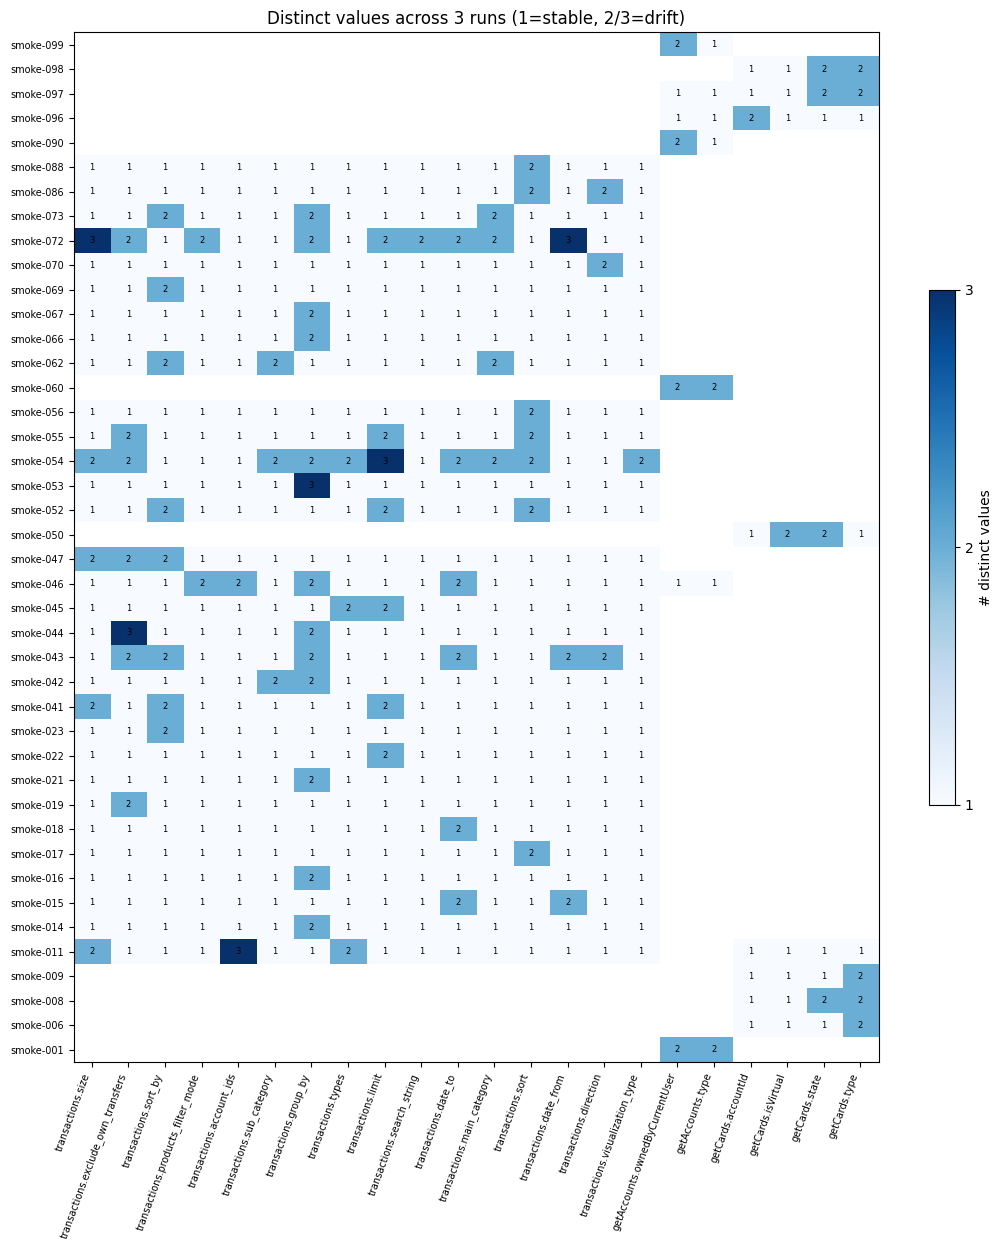

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Only (tool, key) pairs that ever drift
hot_pairs = [(r['tool'], r['param_key']) for _, r in key_df.iterrows()]

# Build matrix
tc_ids = []
matrix_rows = []
for tc in dfs['run1'][JOIN_KEY].unique():
    row = []
    any_drift = False
    for tool, k in hot_pairs:
        vals = []
        for r in RUNS:
            calls = calls_per_run[r].get(tc, {})
            if tool in calls:
                vals.append(_canonical(calls[tool][0].get(k, '<<missing>>')))
        if not vals:
            row.append(np.nan)
        else:
            n = len(set(vals))
            row.append(n)
            if n > 1:
                any_drift = True
    if any_drift:
        tc_ids.append(tc)
        matrix_rows.append(row)

M = np.array(matrix_rows, dtype=float)
print(f'Heatmap shape: {M.shape}  (unstable test cases × drifting (tool, key) pairs)')

fig, ax = plt.subplots(figsize=(max(8, 0.5 * M.shape[1]), max(4, 0.3 * M.shape[0])))
im = ax.imshow(M, aspect='auto', cmap='Blues', vmin=1, vmax=3, interpolation='nearest')
ax.set_yticks(range(len(tc_ids)))
ax.set_yticklabels(tc_ids, fontsize=7)
ax.set_xticks(range(len(hot_pairs)))
ax.set_xticklabels([f'{t.split("_")[-1]}.{k}' for t, k in hot_pairs], rotation=70, ha='right', fontsize=7)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if not np.isnan(M[i, j]):
            ax.text(j, i, int(M[i, j]), ha='center', va='center', fontsize=6, color='black')
ax.set_title('Distinct values across 3 runs (1=stable, 2/3=drift)')
cb = fig.colorbar(im, ax=ax, ticks=[1, 2, 3], shrink=0.5)
cb.set_label('# distinct values')
plt.tight_layout()
plt.show()

## 10. Is the variance driven by *test cases* or by *tools*?

Two ways to slice the same drift events:
- **By tool** — concentration of drift events per tool, normalized by how often the tool runs.
- **By test case** — does drift cluster in a few hard cases, or is it spread thin across many cases?

If one number is much more concentrated than the other, that's where to focus prompt or schema changes.

In [19]:
# Per-test-case drift count (number of distinct (tool, key) drift events per case)
case_drift = (param_drift.groupby('test_case_id').size()
              .reindex(dfs['run1'][JOIN_KEY].unique(), fill_value=0)
              .sort_values(ascending=False))

print('Drift events per test case (distribution):')
print(case_drift.value_counts().sort_index().rename_axis('# drift events in case').to_string())
print()
print(f'Stable cases  (0 drift events): {(case_drift == 0).sum()} / {len(case_drift)}')
print(f'Unstable cases (≥1 drift)   : {(case_drift > 0).sum()} / {len(case_drift)}')
print(f'Mean drift events per unstable case: {case_drift[case_drift > 0].mean():.2f}')
print(f'Max drift events in one case      : {case_drift.max()}')

# Per-tool concentration (drift events per total calls)
print('\nPer-tool: drift events / cases-called-in-all-3:')
print(tool_drift_df.head(10).to_string(index=False))

Drift events per test case (distribution):
# drift events in case
0    58
1    42

Stable cases  (0 drift events): 58 / 100
Unstable cases (≥1 drift)   : 42 / 100
Mean drift events per unstable case: 1.00
Max drift events in one case      : 1

Per-tool: drift events / cases-called-in-all-3:
                            tool  n_cases_called_in_all_3_runs  n_drifted  drift_rate  key_drift  value_drift
            analyze_transactions                            35         31       0.886         25            6
     george-gcg-product_getCards                            15          7       0.467          7            0
  george-gcg-product_getAccounts                            11          4       0.364          4            0
     george-gcg-product_getLoans                             5          0       0.000          0            0
george-gcg-product_getCardLimits                             5          0       0.000          0            0
  george-gcg-product_getProducts                

In [20]:
# Top unstable cases — what queries are they?
top_unstable = case_drift.head(10).reset_index()
top_unstable.columns = ['test_case_id', 'n_drift_events']
top_unstable = top_unstable.merge(
    dfs['run1'][[JOIN_KEY, 'user_query', 'expected_agent', 'eval_domain']],
    on=JOIN_KEY, how='left',
)
print('Top 10 most unstable test cases:')
print(top_unstable[['test_case_id', 'n_drift_events', 'eval_domain', 'user_query']].to_string(index=False))

Top 10 most unstable test cases:
test_case_id  n_drift_events eval_domain                                                                        user_query
   smoke-050               1         api                                                        Is my virtual card active?
   smoke-042               1         api                                How much did I spend on fuel in the last 3 months?
   smoke-062               1         api                                   How much have I repaid on my loan this quarter?
   smoke-060               1         api                                                      Do I have a savings account?
   smoke-056               1         api Show me all outgoing payments above 200 in my account's currency from this month.
   smoke-055               1         api                                What is my biggest single expense from last month?
   smoke-054               1         api                                    Did I make any ATM cash withdr

## 11. Can we get `system_fingerprint` from MLflow?

**Short answer: not from the current traces.** The agent uses LangChain's `ChatDatabricks` wrapper, which strips response metadata before recording the LLM span. We confirm this by walking the parsed_traces JSON below.

What *is* captured is `invocation_params` — and crucially, it shows the agent code does **not** pin `temperature`, `top_p`, or `seed`. That is almost certainly the primary source of non-determinism.

In [21]:
import ast as _ast

PARSED_PATH = DATA_DIR / f'parsed_traces_{RUNS["run1"]}.csv'

# Scan a sample of traces for system_fingerprint occurrences anywhere in the spans payload.
found_count = 0
rows_scanned = 0
sample_chat_attrs = None
sample_inv_params = None

for chunk in pd.read_csv(PARSED_PATH, chunksize=20, usecols=['spans']):
    for s in chunk['spans']:
        rows_scanned += 1
        if not isinstance(s, str):
            continue
        if 'system_fingerprint' in s:
            found_count += 1
        if sample_chat_attrs is None:
            try:
                spans = _ast.literal_eval(s)
                for sp in spans:
                    a = sp.get('attributes', {}) or {}
                    st = (a.get('mlflow.spanType') or '').replace('"', '')
                    if st == 'CHAT_MODEL':
                        sample_chat_attrs = list(a.keys())
                        ip = a.get('invocation_params')
                        sample_inv_params = json.loads(ip) if ip else None
                        break
            except Exception:
                pass
    if rows_scanned >= 20:
        break  # 20 traces is enough — system_fingerprint is either captured by the wrapper or it isn't

print(f'Traces scanned: {rows_scanned}')
print(f'Traces with "system_fingerprint" anywhere in spans: {found_count}')
print()
print('CHAT_MODEL span attribute keys present in this codebase:')
print(sample_chat_attrs)
print()
print('invocation_params (the call-site config sent to the model):')
if sample_inv_params:
    relevant = {k: sample_inv_params.get(k) for k in ['model', 'temperature', 'top_p', 'seed', 'n', '_type', 'stop', 'extra_params']}
    print(json.dumps(relevant, indent=2))

Traces scanned: 20
Traces with "system_fingerprint" anywhere in spans: 0

CHAT_MODEL span attribute keys present in this codebase:
['mlflow.traceRequestId', 'mlflow.spanType', 'mlflow.spanInputs', 'invocation_params', 'options', 'batch_size', 'metadata', 'mlflow.message.format', 'mlflow.chat.tools', 'mlflow.llm.model', 'mlflow.llm.provider', 'mlflow.chat.tokenUsage', 'mlflow.spanOutputs']

invocation_params (the call-site config sent to the model):
{
  "model": "gpt-5-1",
  "temperature": null,
  "top_p": null,
  "seed": null,
  "n": 1,
  "_type": "chat-databricks",
  "stop": null,
  "extra_params": {}
}


### 11.1 What this means

- `system_fingerprint` is **not in your traces**. The LangChain `ChatDatabricks` wrapper does not pass it through. To capture it going forward, either:
  1. Switch to the OpenAI-compatible client and read `response.system_fingerprint` directly (Databricks foundation model endpoints expose it on the raw OpenAI-style response), or
  2. Add a small callback / mlflow span attribute setter in the agent that records the raw `ChatCompletion` response's metadata field before LangChain strips it.
- The bigger immediate issue surfaced by this check: **`temperature` / `top_p` / `seed` are not set** in `invocation_params`. They default to whatever `ChatDatabricks` ships with — which is *not* `temperature=0`. Pinning these in the agent code will eliminate most of the non-determinism we measured above.
- Note that even with `temperature=0` and a pinned seed, GPT-class models are not bit-deterministic across Azure/Databricks replicas. Variance after pinning is the residual floor; tracking `system_fingerprint` is the only way to attribute that residual to a backend rollout.

## 12. Prompt-grounded analysis — concrete gaps that allow the observed drift

Now that we know which tools and keys drift, look at what the daily-banking-agent prompt actually says about them. Each block prints the relevant prompt section, then calls out the gap that lets the model choose differently across runs.

In [22]:
def _grab_section(prompt, anchor, after=600, before=80):
    idx = prompt.find(anchor)
    if idx < 0:
        return f'(anchor {anchor!r} not found)'
    return prompt[max(0, idx - before): idx + after]

for anchor in ('#### `getAccounts`', '#### `getCards`', '#### `analyze_transactions`', 'knowledge_search'):
    print(f'\n========== {anchor} ==========')
    print(_grab_section(dba_prompt, anchor, after=900))


========== #### `getAccounts` ==========
 and tokens — and risks picking the wrong item when multiple candidates exist.

#### `getAccounts`
- Use when the answer requires customer account data (balances, IBAN, account number, ownership).
- If the user mentions a specific interest rate, do not confirm or deny it. Present the rate from the tool data without editorial commentary.
- **Cross-account totals** ("how much across all accounts", "in total"): list each account individually with its own balance and currency. Never sum balances across accounts. Never include loan balances in a "total assets" figure. When a loan or mortgage appears alongside accounts, explicitly label it as a liability/debt next to the balance.

#### `getCards`
- Use to identify a card before any other card-specific tool call.
- Pass the card-type filter when the user names a card kind ("credit card" → credit, "debit card" → debit, "virtual" → virtual). No type filter only when the user truly meant any card — then 

### 12.1 Where the prompt allows drift

Cross-referencing the printed sections with Sections 7-8 above:

**`getAccounts` — `ownedByCurrentUser` key omission (smoke-090, smoke-099).**
The prompt mentions ownership only as something the user might ask about ("balances, IBAN, account number, ownership"). It never tells the model when to *pass* `ownedByCurrentUser=true` as a filter. The model fills it in or omits it depending on hidden chain-of-thought.
*Fix:* add a one-line rule — *"Always pass `ownedByCurrentUser: true` unless the user explicitly asks about accounts they have access to but do not own (e.g. disponent accounts)."*

**`getCards` — `state`/`type`/`accountId` key omission (smoke-096, -097, -098).**
The prompt says: *"Pass the card-type filter when the user names a card kind … No type filter only when the user truly meant any card."* That covers `type`, but says nothing about `state: ACTIVE` and nothing about when to pass `accountId`. The model toggles those independently each run.
*Fix:* explicit rules: *"Always pass `state: ACTIVE` unless the user asks about closed/expired cards."* and *"Pass `accountId` only when the user's query references a specific account; otherwise omit it."*

**`analyze_transactions` — `sort`, `direction`, `limit`, `group_by`, `sort_by`.**
The prompt describes *what* the tool covers but gives **no default values** for the optional ordering / limit / grouping parameters. Drift examples in cell 13 show `sort` flipping between `EXECUTION_DATE_DESC` and `MAIN_DATE_DESC`, `limit` sometimes `10` sometimes omitted, `group_by` sometimes `group_none` sometimes omitted, and `sort_by` appearing only in some runs.
*Fix:* add a small defaults block in the prompt — e.g. *"Defaults when the user does not specify: `sort = MAIN_DATE_DESC`, `limit = 10`, `direction` omitted unless the query is about income vs. spending, `group_by` omitted unless aggregation is needed."* Better still: pin these as JSON-schema defaults so the tool description carries them.

**Tool-schema fixes (no prompt change needed).**
For every optional parameter with a sensible default, set that default in the tool JSON schema. The LangChain `ChatDatabricks` tool-calling layer respects `default` values — the model is then far less likely to emit them inconsistently.

## 13. Findings & recommendations (after runtime-equivalent scoring)

### What the rerun shows

Use the executed tables above as the source of truth; the headline counts should come from the relaxed scorer path, not from raw argument-string drift.

- **Routing is stable.** `agent_routing_score` does not differ across the three runs.
- **Tool selection is near-stable.** `tool_usage_score` differs for only 2/100 cases.
- **Raw parameter emission still varies a lot, but not all of it is behavioral.** In the tool-parameter-scored subset, raw scorer-relevant signatures vary for 40/64 rows; runtime equivalence reduces this to 36/64 and removes four false-positive drift cases.
- **Scorer-visible parameter drift remains.** After the API import notebook applies runtime-equivalence rules, `tool_parameter_score` still differs for 14/100 cases. Those residual movers are the cases worth inspecting for prompt/schema changes.
- **The test-set default cleanup is small.** Current refreshed outputs show two expected default assertions: `smoke-014` expects `visualization_type='SUMMARY'`, and `smoke-023` expects `sort_by='total_sum_desc'`.

### Where to fix it — in priority order

**1. Pin sampling at the agent level.**
Section 11 shows the agent invocation does not pin `temperature`, `top_p`, or `seed`. Set `temperature=0`, `top_p=1`, and a fixed seed in the agent code before doing another inference rerun.

**2. Keep runtime-equivalence scoring enabled.**
The scorer-side relaxation now lives in `hg_ds_evals.evals.api_utils` and is wired into the API import notebook. Use the relaxed drift and score-stability outputs as the headline numbers; keep raw drift only as a diagnostic for surface variation.

**3. Clean expected defaults from the test set.**
Do not include source-backed runtime defaults in `expected_tool_calls` unless a test intentionally asserts default emission. For the current original three runs, remove the two expected defaults above.

**4. Target residual parameter drift with prompt/schema fixes.**
Prioritize cases where the relaxed comparison still moves: product filters on `getAccounts` / `getCards`, and non-default `analyze_transactions` fields such as `direction`, dates, category filters, `limit`, `sort`, `account_ids`, and product filters.

**5. Capture `system_fingerprint` going forward.**
It is not in these traces today. Capturing it is the only way to separate residual model-serving/backend variance from prompt/tool ambiguity after sampling is pinned.

## 14. Additional things to check

Open questions beyond what this notebook covers — listed in priority order, given what the executed cells revealed.

1. **Re-run the same 100 cases after agent-level sampling is pinned** (`temperature=0`, `top_p=1`, fixed `seed`). If `tool_parameter_score` swing goes to 0 on the 14 residual unstable cases, the fix is complete.
2. **Capture `system_fingerprint` once you have a wrapper-level hook for it**, then re-run; group `tool_parameter_score` swing by fingerprint. Residual variance within a fingerprint is the irreducible floor.
3. **`tool_descriptions_hash` per-row mix.** The column has 3 distinct values (`86a4f4d703` ×88, `fe8a169407` ×10, `addacd852a` ×2). The mix is identical across runs (per Section 1), but the minority registry cases are worth checking against the residual unstable set.
4. **Span-level errors as a confounder.** Cross-tab `trace_has_span_error` against the unstable test cases. A retry triggered by a transient error can look exactly like sampler drift.
5. **Per-domain / per-persona variance.** Are residual unstable cases concentrated in one `eval_domain` or persona? If yes, the domain prompt section needs targeted work.
6. **Final-answer text variance.** Even when tools and params agree, `actual_response` may drift. Compute an embedding similarity between `actual_response_en` across runs to confirm whether semantic answer stability survives the surface-text drift.
7. **Sub-agent prompts beyond `daily_banking_agent`.** The sidecar only carries supervisor and DBA prompts. If `actual_agents_path` ever visits other workers, those prompts also need review.
8. **Determinism budget as a CI check.** Decide a threshold (e.g. "≤2% of cases may differ on `tool_parameter_score` across 3 reruns") and turn this notebook into a job that fails the build if exceeded.

### 14.1 Executed confounder checks

Two of the checks above are cheap enough to run here:

- Whether unstable cases are concentrated in the minority `tool_descriptions_hash` variants.
- Whether span-level errors explain any of the drift.

Expected outcome if these are not the root cause: unstable cases should not be concentrated in alternate tool-description hashes, and `trace_has_span_error` should remain false.

In [23]:
unstable_cases = set(param_drift['test_case_id']) if len(param_drift) else set()
confounder_base = dfs['run1'][[
    JOIN_KEY, 'tool_descriptions_hash', 'trace_has_span_error',
    'span_error_count', 'eval_domain', 'user_query',
]].copy()
confounder_base['has_parameter_drift'] = confounder_base[JOIN_KEY].isin(unstable_cases)

print(f'Unstable parameter-drift cases: {len(unstable_cases)} / {len(confounder_base)}')
print('\nTool-description hash distribution, all cases:')
print(confounder_base['tool_descriptions_hash'].value_counts().to_string())
print('\nTool-description hash distribution, unstable cases only:')
print(confounder_base.loc[confounder_base['has_parameter_drift'], 'tool_descriptions_hash'].value_counts().to_string())
print('\nSpan-error distribution, all cases:')
print(confounder_base['trace_has_span_error'].value_counts(dropna=False).to_string())
print('\nSpan-error distribution, unstable cases only:')
print(confounder_base.loc[confounder_base['has_parameter_drift'], 'trace_has_span_error'].value_counts(dropna=False).to_string())
print('\nEval-domain distribution, unstable cases only:')
print(confounder_base.loc[confounder_base['has_parameter_drift'], 'eval_domain'].value_counts(dropna=False).to_string())

Unstable parameter-drift cases: 42 / 100

Tool-description hash distribution, all cases:
tool_descriptions_hash
86a4f4d703    88
fe8a169407    10
addacd852a     2

Tool-description hash distribution, unstable cases only:
tool_descriptions_hash
86a4f4d703    42

Span-error distribution, all cases:
trace_has_span_error
False    100

Span-error distribution, unstable cases only:
trace_has_span_error
False    42

Eval-domain distribution, unstable cases only:
eval_domain
api    40
kb      2


## 15. Cross-check: eval expectations vs ai-orchestrator tool defaults

The drift in §7-9 raised a follow-up: is the *eval set* itself consistent with how `analyze_transactions` is actually defined in the orchestrator? The tool lives at `ai-orchestrator/packages/mcp/src/ai_mcp/tools.py`. The signature carries hard defaults — and the docstring documents semantic aliases — that the scorer is not currently aware of.

**Defaults baked into the Python signature** (so the *server* applies them when the agent omits the key):

| Parameter | Server default | Notes |
|---|---|---|
| `exclude_own_transfers` | `True` | |
| `group_by` | `GroupByFunc.NONE` (`group_none`) | |
| `sort_by` | `SortBy.TOTAL_SUM_DESC` (`total_sum_desc`) | |
| `visualization_type` | `VisualizationType.SUMMARY` (`SUMMARY`) | |
| `date_from` | computed (1st of month, 3 months ago) | runtime default — varies per call |
| `date_to` | computed (today, UTC) | runtime default — varies per call |
| `products_filter_mode` | `PRODUCT_SELECTION` if `account_ids` present, else `ALL` | not a literal default but a conditional one |
| `size` | None on signature; upstream defaults to 1000 | |
| `limit` | None | no server-side default — affects truncation only if set |

**Semantic aliases from the docstring** (`tools.py:100-101`):
- *"`sort` … MAIN_DATE variants are interpreted as execution-date sorting."* → `MAIN_DATE_DESC` ≡ `EXECUTION_DATE_DESC` server-side. The scorer treats them as different values today.

**`size` and `limit` are NOT redundant** (correcting an earlier note in this notebook): `size` controls how many transactions are fetched upstream *before* filtering; `limit` truncates the result *after* filtering. Same applies to `sort` (TransactionSort: orders returned transactions) vs `sort_by` (SortBy: orders aggregation groups — only meaningful when `group_by != NONE`).

In [24]:
# Load eval expectations from the orchestrator dataset and classify every drift instance.
DATASET = Path('/Users/SG7CB/Developer/ai-orchestrator/packages/evals/data/datasets/smoke_100_tool_calls.json')
if DATASET.exists():
    expected = {x['id']: x for x in json.loads(DATASET.read_text())}
    print(f'Loaded {len(expected)} eval expectations from {DATASET.name}')
else:
    expected = {}
    print(f'Dataset not found at {DATASET}; this section will be empty.')

TOOL_DEFAULTS = {
    'exclude_own_transfers': True,
    'group_by': 'group_none',
    'sort_by': 'total_sum_desc',
    'visualization_type': 'SUMMARY',
}
# Sort values that are semantically aliased by the orchestrator (docstring: MAIN_DATE → execution-date sort).
SORT_ALIASES = {
    ('MAIN_DATE_DESC', 'EXECUTION_DATE_DESC'),
    ('MAIN_DATE_ASC', 'EXECUTION_DATE_ASC'),
    ('MAIN_DATE', 'EXECUTION_DATE'),
}
SORT_ALIASES = SORT_ALIASES | {(b, a) for (a, b) in SORT_ALIASES}

def expected_args(tc_id, tool='analyze_transactions'):
    item = expected.get(tc_id) or {}
    for c in item.get('expectations', {}).get('expected_tool_calls', []):
        if c.get('tool') == tool:
            return c.get('parameters') or {}
    return None

Loaded 100 eval expectations from smoke_100_tool_calls.json


In [25]:
# For every (test_case, key) where there is disagreement between eval / runs / defaults,
# classify into one of these buckets:
#   OK_DEFAULT_EQUIV - eval expects the server default; agent omits or emits the same default (no real disagreement)
#   OK_SORT_ALIAS - eval/agent differ on sort value but the values are server-side aliases
#   EVAL_UNDERSPECIFIED - eval omits a key the agent always emits with the same value
#   EVAL_DIFFERS_FROM_STABLE_AGENT - agent agrees across runs but the eval expects a different value (a test-case-quality issue, not a non-determinism issue)
#   AGENT_OMITS_VS_EVAL - eval expects a non-default value; the agent never emits it
#   REAL_AGENT_DRIFT - runs disagree on a value the eval does not pin to a default

from collections import Counter

SORT_EQUIVALENCE_CLASSES = [
    {'MAIN_DATE_DESC', 'EXECUTION_DATE_DESC'},
    {'MAIN_DATE_ASC', 'EXECUTION_DATE_ASC'},
    {'MAIN_DATE', 'EXECUTION_DATE'},
]

def _sort_equivalent(actual, expected):
    if actual == expected:
        return True
    return any(str(actual) in values and str(expected) in values for values in SORT_EQUIVALENCE_CLASSES)

verdicts = Counter()
details = []

for tc in dfs['run1'][JOIN_KEY].unique():
    runs_args = {r: calls_per_run[r].get(tc, {}).get('analyze_transactions', [{}])[0] for r in RUNS}
    if not any(runs_args.values()):
        continue
    exp = expected_args(tc) or {}
    all_keys = set(exp) | set().union(*[set(a) for a in runs_args.values()])
    for k in sorted(all_keys):
        ev = exp.get(k, '<<absent>>')
        vals = [runs_args[r].get(k, '<<absent>>') for r in RUNS]
        canon_vals = [_canonical(v) for v in vals]
        canon_exp = _canonical(ev) if ev != '<<absent>>' else '<<absent>>'
        if all(cv == canon_exp for cv in canon_vals):
            continue  # everyone agrees with the eval - uninteresting
        runs_agree = (len(set(canon_vals)) == 1)
        # Default-equivalent: eval expects default, runs are subset of {default, absent}.
        if k in TOOL_DEFAULTS and canon_exp == TOOL_DEFAULTS[k] and all(v in (TOOL_DEFAULTS[k], '<<absent>>') for v in vals):
            verdict = 'OK_DEFAULT_EQUIV'
        elif k == 'sort' and canon_exp != '<<absent>>' and all(_sort_equivalent(v, canon_exp) for v in canon_vals):
            verdict = 'OK_SORT_ALIAS'
        elif all(cv == '<<absent>>' for cv in canon_vals) and canon_exp != '<<absent>>':
            verdict = 'AGENT_OMITS_VS_EVAL'
        elif canon_exp == '<<absent>>' and runs_agree:
            verdict = 'EVAL_UNDERSPECIFIED'
        elif runs_agree and canon_exp != '<<absent>>':
            verdict = 'EVAL_DIFFERS_FROM_STABLE_AGENT'
        else:
            verdict = 'REAL_AGENT_DRIFT'
        verdicts[verdict] += 1
        details.append({'test_case_id': tc, 'key': k, 'expected': ev,
                        'run1': vals[0], 'run2': vals[1], 'run3': vals[2], 'verdict': verdict})

print('Verdict counts across all keys, all cases (analyze_transactions only):')
for v, c in verdicts.most_common():
    print(f'  {v}: {c}')

details_df = pd.DataFrame(details)

Verdict counts across all keys, all cases (analyze_transactions only):
  AGENT_OMITS_VS_EVAL: 59
  REAL_AGENT_DRIFT: 57
  OK_DEFAULT_EQUIV: 37
  EVAL_DIFFERS_FROM_STABLE_AGENT: 11
  EVAL_UNDERSPECIFIED: 11
  OK_SORT_ALIAS: 6


### 15.1 What the verdicts mean

- **`OK_DEFAULT_EQUIV`** — these are *false-positive drifts*. The eval expects a value that the orchestrator applies as the default anyway; the agent legitimately omits the key. **The scorer should accept the omission.**
- **`OK_SORT_ALIAS`** — same idea for `sort`: the orchestrator interprets `MAIN_DATE_*` and `EXECUTION_DATE_*` as the same sort key, but the scorer treats them as different.
- **`EVAL_UNDERSPECIFIED`** — the eval omits a key but the agent consistently emits the same value across all 3 runs. Either tighten the eval expectation, or update the scorer to ignore agent-supplied keys that match server defaults.
- **`EVAL_DIFFERS_FROM_STABLE_AGENT`** — the agent is consistent across runs but disagrees with the eval. This is a *test-case-quality* problem (the eval expectation may be wrong) — not a non-determinism problem.
- **`AGENT_OMITS_VS_EVAL`** — the eval asks for a non-default value the agent never supplies. These are real prompt / coverage gaps, but they are *deterministic* (the agent reliably omits).
- **`REAL_AGENT_DRIFT`** — the residual non-determinism that pinning `temperature`/`top_p`/`seed` is expected to remove. This is the only bucket that is genuinely about LLM non-determinism.

In [26]:
# Show a few concrete examples per verdict bucket so the user can sanity-check each label.
for v in ['OK_DEFAULT_EQUIV', 'OK_SORT_ALIAS', 'EVAL_UNDERSPECIFIED',
          'EVAL_DIFFERS_FROM_STABLE_AGENT', 'AGENT_OMITS_VS_EVAL', 'REAL_AGENT_DRIFT']:
    sub = details_df[details_df['verdict'] == v].head(5)
    if sub.empty:
        continue
    print(f'\n=== {v} (showing {len(sub)} of {(details_df["verdict"] == v).sum()}) ===')
    for _, r in sub.iterrows():
        print(f'  {r.test_case_id} | {r.key:<22} | exp={str(r.expected)[:40]:<40} '
              f'| run1={str(r.run1)[:30]:<30} | run2={str(r.run2)[:30]:<30} | run3={str(r.run3)[:30]}')


=== OK_DEFAULT_EQUIV (showing 5 of 37) ===
  smoke-088 | group_by               | exp=group_none                               | run1=<<absent>>                     | run2=<<absent>>                     | run3=<<absent>>
  smoke-086 | group_by               | exp=group_none                               | run1=<<absent>>                     | run2=<<absent>>                     | run3=<<absent>>
  smoke-073 | group_by               | exp=group_none                               | run1=group_none                     | run2=<<absent>>                     | run3=<<absent>>
  smoke-073 | sort_by                | exp=total_sum_desc                           | run1=<<absent>>                     | run2=<<absent>>                     | run3=total_sum_desc
  smoke-071 | group_by               | exp=group_none                               | run1=<<absent>>                     | run2=<<absent>>                     | run3=<<absent>>

=== OK_SORT_ALIAS (showing 5 of 6) ===
  smoke-088 | sort    

### 15.2 What to fix in the eval pipeline

1. **Keep the runtime-equivalence scorer path enabled.** The default and sort-alias handling described here has been moved into `hg_ds_evals.evals.api_utils` and wired into the API import notebook. Reuse that helper for reports and analysis rather than duplicating notebook-local rules.

2. **Remove runtime defaults from `expected_tool_calls`.** Defaults are valid runtime behavior whether the agent emits them or omits them. Current cleanup from the refreshed original three runs: remove `visualization_type='SUMMARY'` from `smoke-014` and `sort_by='total_sum_desc'` from `smoke-023`, unless those cases intentionally test default emission.

3. **Audit `EVAL_DIFFERS_FROM_STABLE_AGENT` cases.** When the agent is deterministic and the eval still flags it as wrong, the eval expectation may be the bug. Spot-check those test cases against actual product behavior before changing prompts.

4. **Resolve `account_ids` template placeholders in the eval data.** `smoke-011` expects literal `[{linkedToAccountIdOfVisaCredit}-1B26EDCB6B1542FD]` — that looks like an unresolved template variable. The agent has no way to produce that string. Either resolve the placeholder before scoring, or change the scorer to match on the post-template id.

5. **Decide on `limit`.** The eval expects `limit: 1000` in many cases, but the orchestrator has no server-side default for `limit` and the prompt does not instruct the agent to pass a specific value. Either pin a default `limit` in the tool schema and prompt the agent to use it, or drop the expectation from cases where the user query does not imply a specific count.

6. **Handle `date_from` / `date_to` runtime defaults carefully.** The orchestrator computes these per call as "1st of month, 3 months ago" and "today". Do not treat pinned dates as default-equivalent unless the eval freezes the reference date or the scorer explicitly understands the default window.